# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
# Ilya Niafiodau, Vlad Zagorodnyuk, Zhanar Sirgebayeva, Skoltech, 2026

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [4]:
# read data from txt files
flux_year, flux_month, flux = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)
sunspot_year, sunspot_month, sunspot = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)

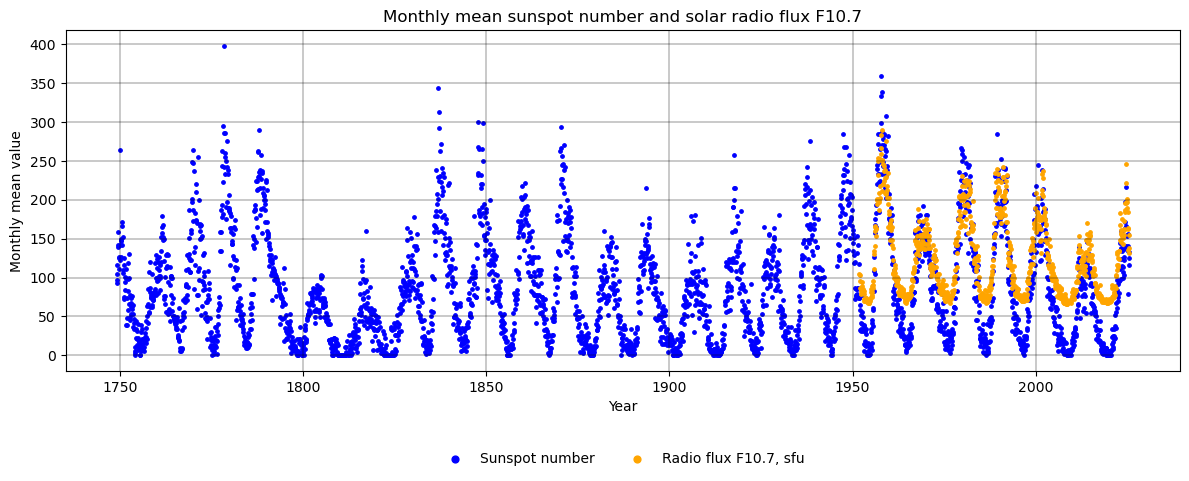

In [5]:
# conver year & month into common scale of time
flux_time    = flux_year    + (flux_month    - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

# plot the data
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux, s=6, color="orange", label="Radio flux F10.7, sfu")
ax.set_title("Monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()
plt.show()

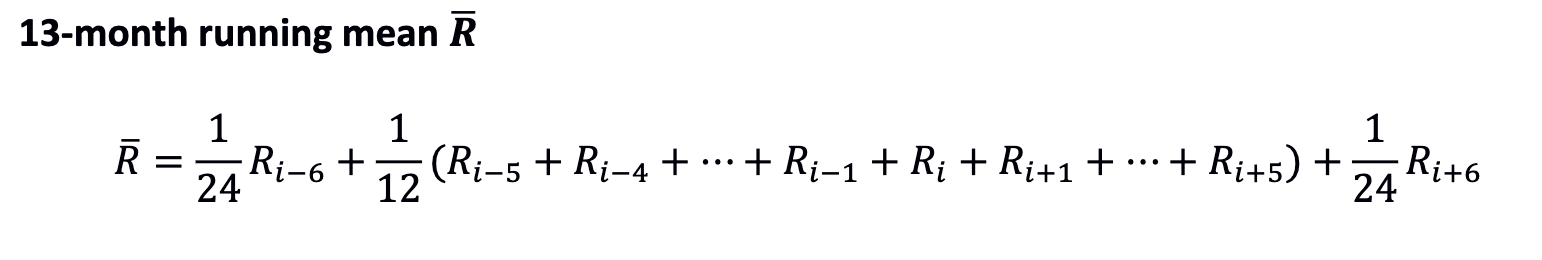

In [6]:
# adjust simple smoothing
def smooth(data, time):
    n = len(time)
    smoothed = data
    for i in range(6, n-6):
        sum = data[i-6] / 24 
        for j in range(i-5, i+6):
            sum += 1 / 12 * data[j]
        sum += data[i+6] / 24
        smoothed[j] = sum
    return smoothed

sunspot_smoothed = smooth(sunspot, sunspot_time)
flux_smoothed = smooth(flux, flux_time)

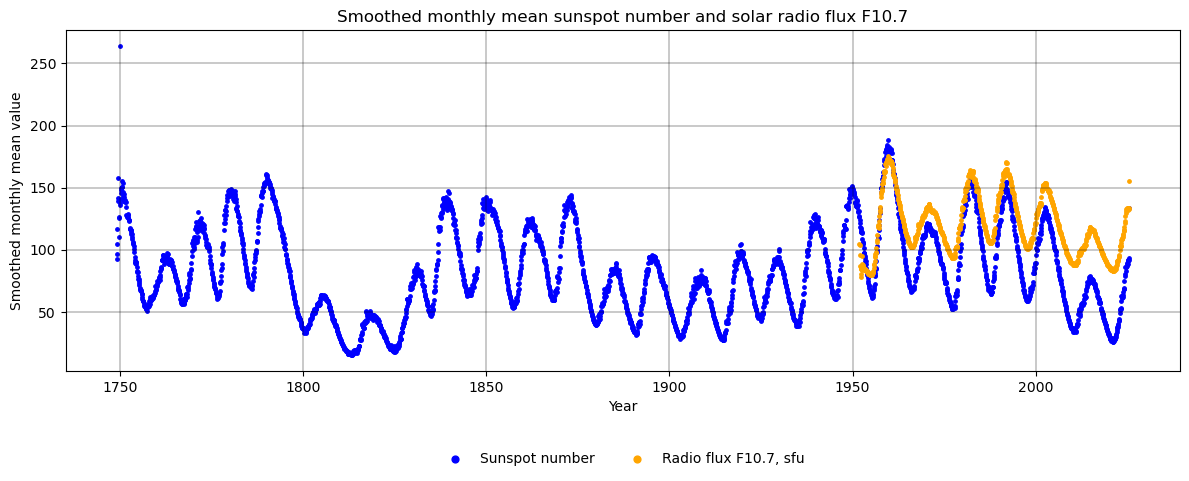

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot_smoothed, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux_smoothed, s=6, color="orange", label="Radio flux F10.7, sfu")
ax.set_title("Smoothed monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Smoothed monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()
plt.show()

1951.8333333333333 2025.5833333333333


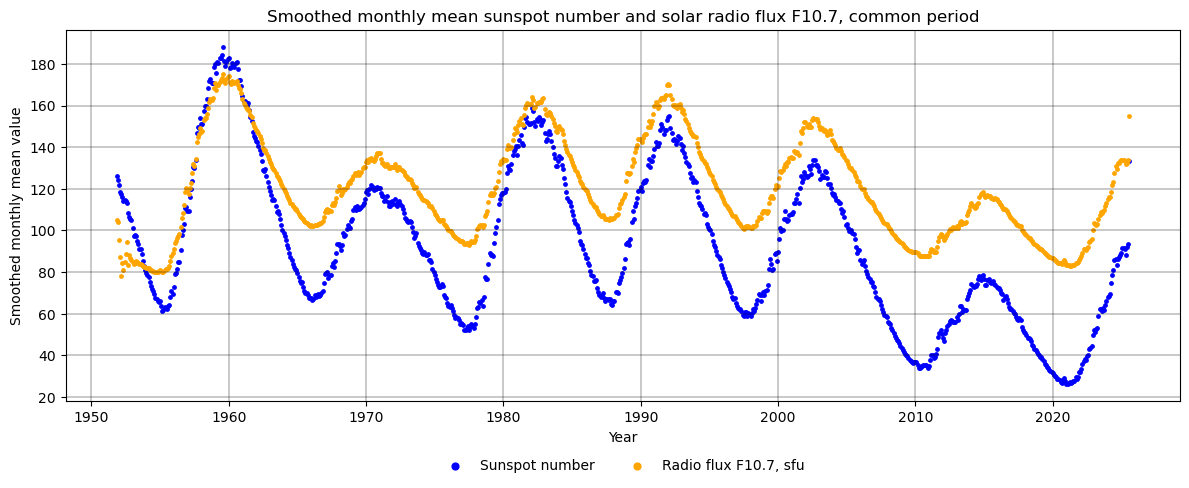

In [8]:
# looking for a comon start time and end time periods
common_start = max(sunspot_time[0], flux_time[0])
common_end = min(sunspot_time[-1], flux_time[-1])
print(common_start, common_end)
sunspot_mask = (sunspot_time >= common_start) & (sunspot_time <= common_end)
flux_mask = (flux_time >= common_start) & (flux_time <= common_end)

# extract data from a common timeline
common_time = sunspot_time[sunspot_mask]
sunspot_common = sunspot[sunspot_mask]
flux_common = flux[flux_mask]
sunspot_smoothed_common = sunspot_smoothed[sunspot_mask]
flux_smoothed_common = flux_smoothed[flux_mask]

# plot graphs
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(common_time, sunspot_common, s=6, color="blue", label="Sunspot number")
ax.scatter(common_time, flux_common, s=6, color="orange", label="Radio flux F10.7, sfu")
ax.set_title("Smoothed monthly mean sunspot number and solar radio flux F10.7, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Smoothed monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

# Conclusions:
both dependencies have:
- same periods
- same max and mins points (extremums)

looks like they have a linear dependency

# Multi-dimensional linear regression model:
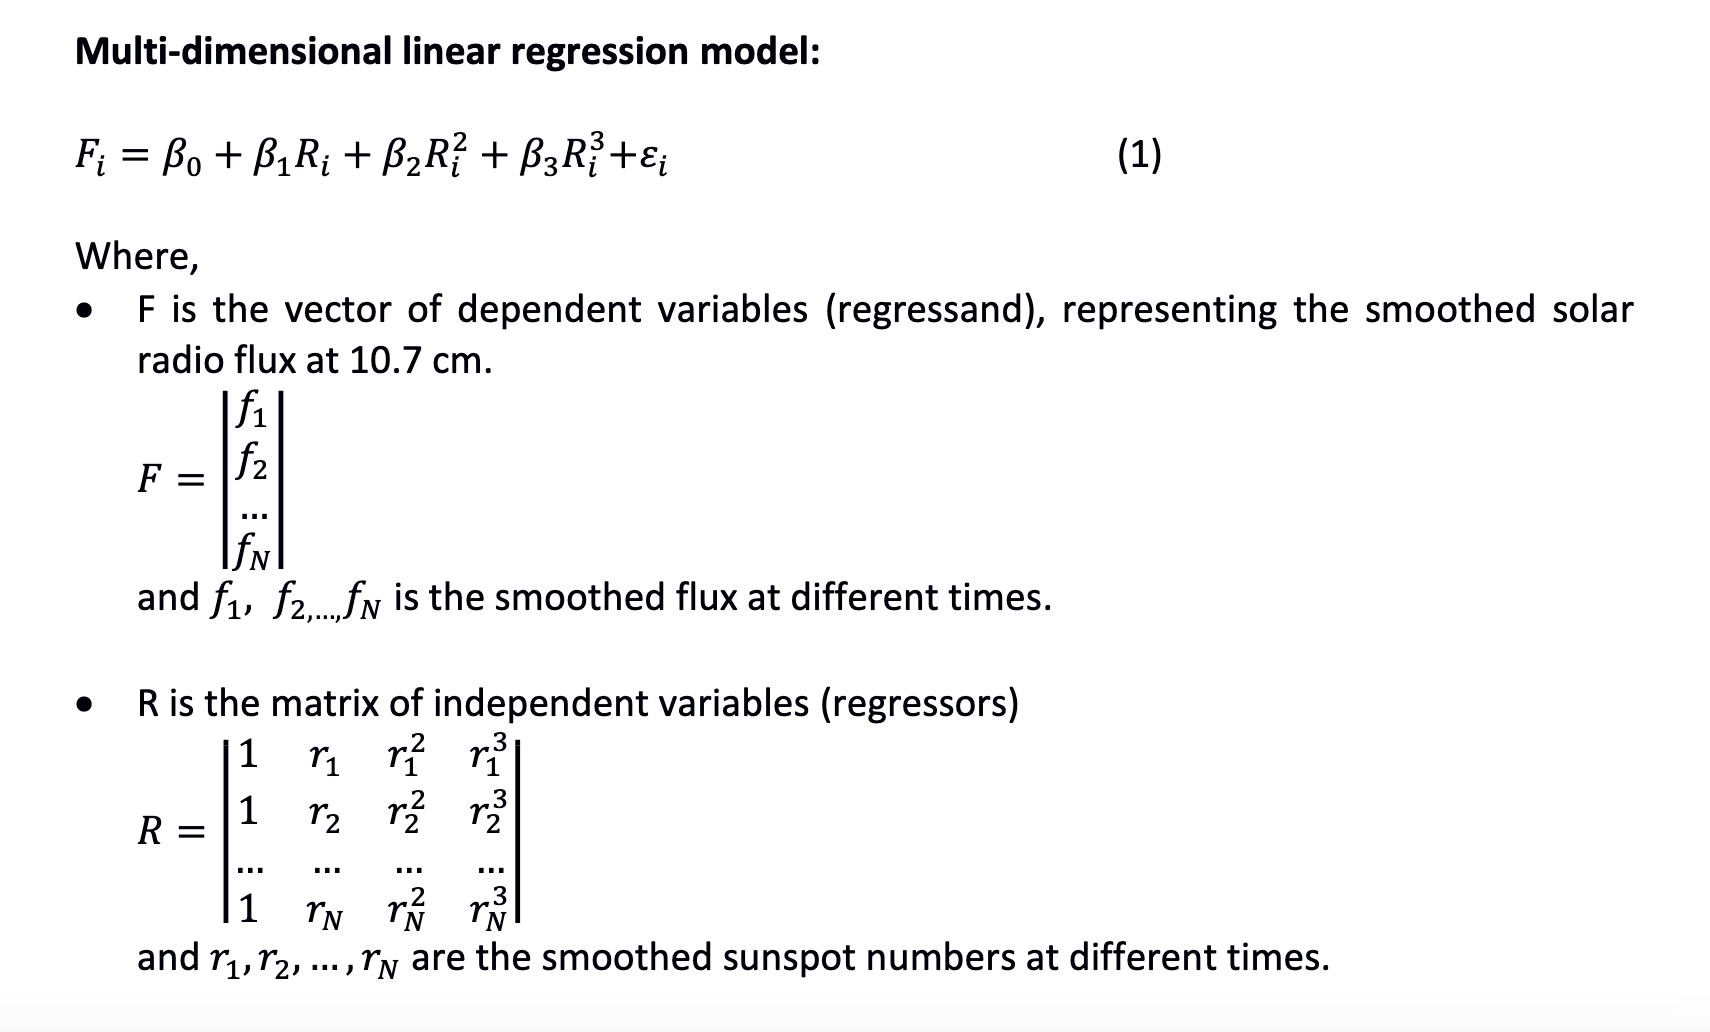
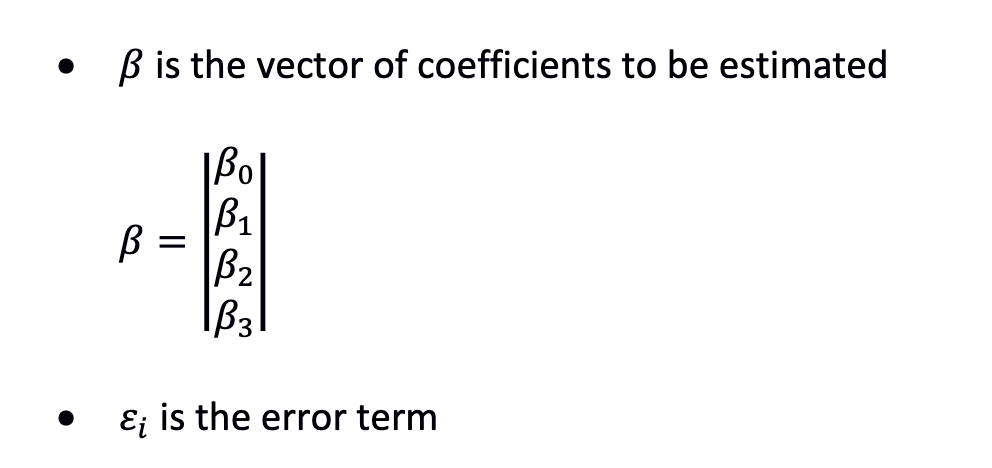

In [9]:
r = sunspot_smoothed_common
f = flux_smoothed_common

# R: (1, r_i, r_i^2, r_i^3) - one row per month
# F: column of f_i
R = np.column_stack((np.ones(r.size), r, r**2, r**3))
F = f.reshape(-1, 1)

# Least squares estimate: beta = (R^T R)^-1 R^T F
beta = np.linalg.inv(R.T @ R) @ R.T @ F

print("R:", R.shape, " F:", F.shape, " beta:", beta.shape)
print(beta)

R: (886, 4)  F: (886, 1)  beta: (4, 1)
[[ 8.35861022e+01]
 [-2.65666514e-02]
 [ 5.90278073e-03]
 [-1.67057295e-05]]


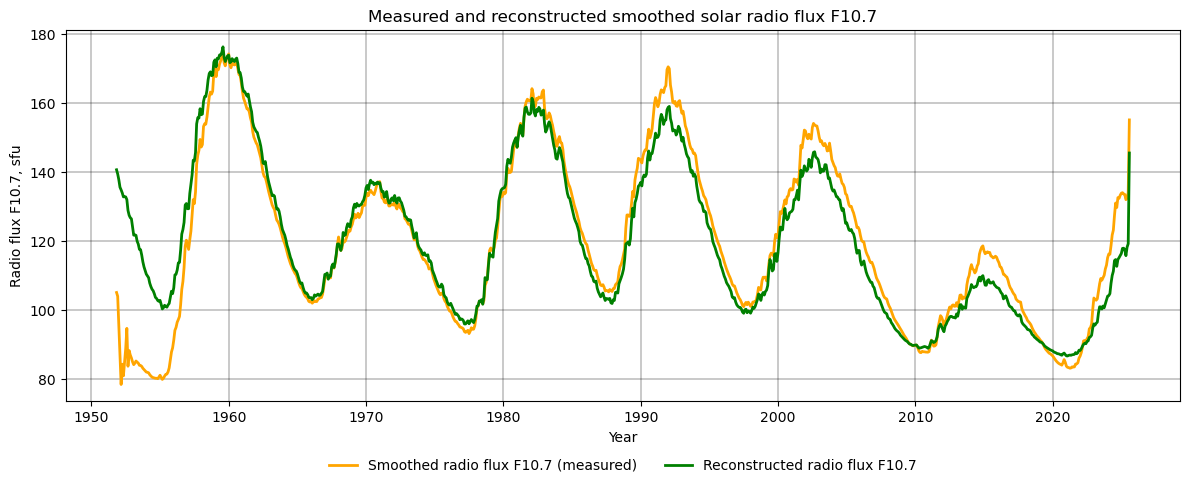

In [10]:
# reconstruct smoothed flux
# F = beta0 + beta1*r + beta2*r^2 + beta3*r^3
F_reconstructed = R @ beta
flux_reconstructed = F_reconstructed.ravel()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(common_time, flux_smoothed_common, linewidth=2, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.plot(common_time, flux_reconstructed, linewidth=2, color="green", label="Reconstructed radio flux F10.7")
ax.set_title("Measured and reconstructed smoothed solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

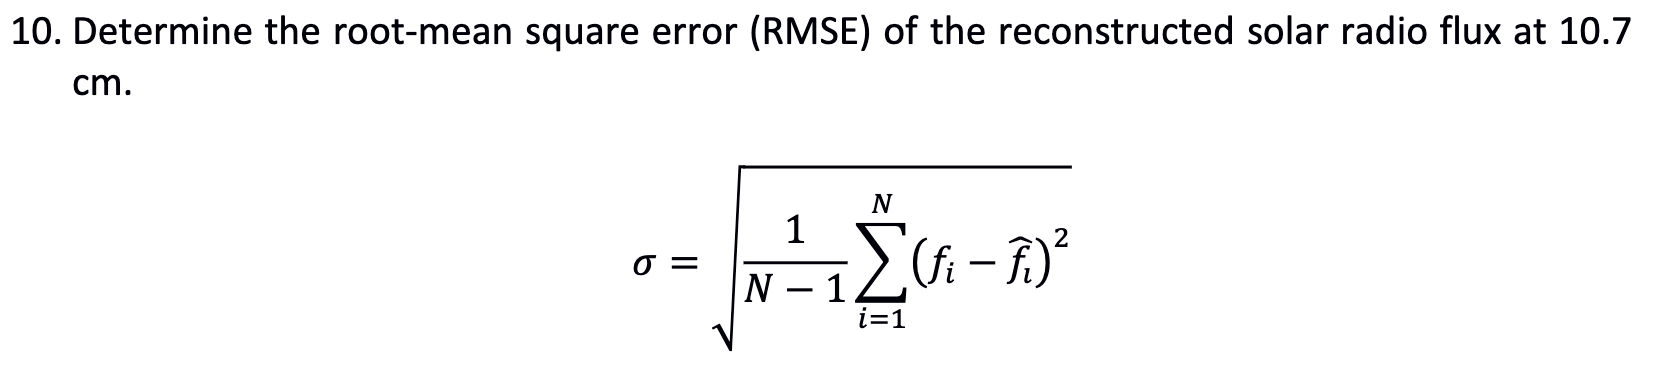

In [11]:
from math import sqrt
rmse = sqrt(((flux_reconstructed - flux_smoothed_common) ** 2).sum() / (len(flux_smoothed_common)-1))
print(rmse, 3*rmse)

9.39305989087717 28.179179672631513


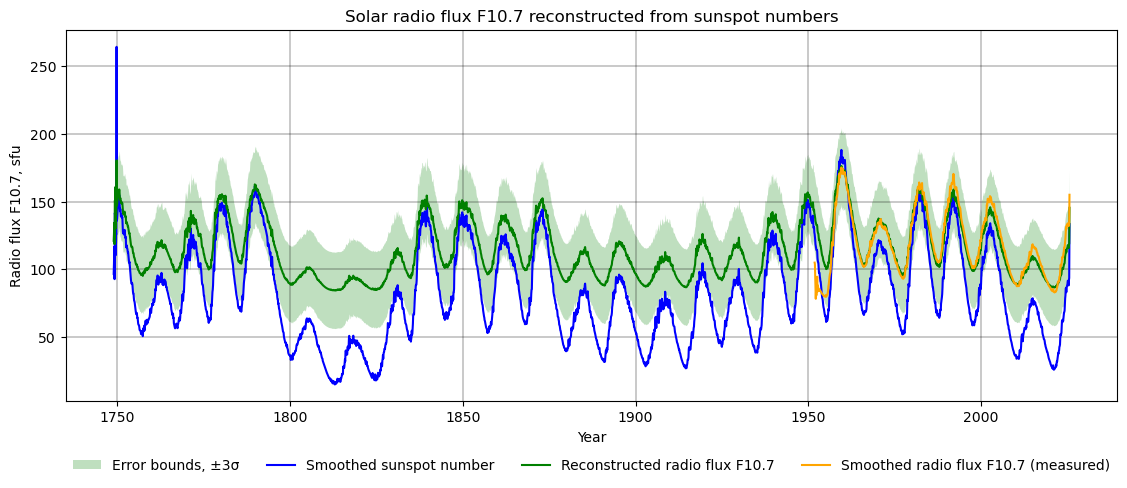

In [12]:
# apply the model to the whole period where sunspot numbers are available
r_full = sunspot_smoothed
R_full = np.column_stack((np.ones(r_full.size), r_full, r_full**2, r_full**3))
flux_reconstructed_full = (R_full @ beta).ravel()

# error bounds: +-3 sigma
flux_full_lower = flux_reconstructed_full - 3 * rmse
flux_full_upper = flux_reconstructed_full + 3 * rmse

# plotting
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(sunspot_time, flux_full_lower, flux_full_upper, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.plot(sunspot_time, sunspot_smoothed, linewidth=1.5, color="blue", label="Smoothed sunspot number")
ax.plot(sunspot_time, flux_reconstructed_full, linewidth=1.5, color="green", label="Reconstructed radio flux F10.7")
ax.plot(common_time, flux_smoothed_common, linewidth=1.5, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.set_title("Solar radio flux F10.7 reconstructed from sunspot numbers")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

measured points inside ±3σ: 859 of 886 (97.0%)


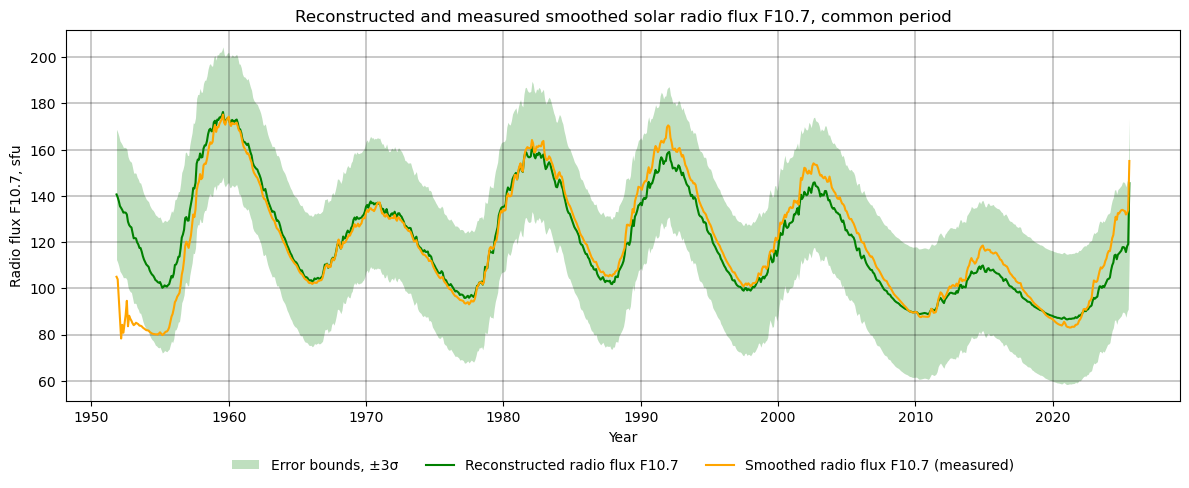

In [13]:
# reconstructed model with +-3 sigma band and measured points on the common period
flux_common_lower = flux_reconstructed - 3 * rmse
flux_common_upper = flux_reconstructed + 3 * rmse

inside = (flux_smoothed_common >= flux_common_lower) & (flux_smoothed_common <= flux_common_upper)
print(f"measured points inside ±3σ: {inside.sum()} of {inside.size} ({100 * inside.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(common_time, flux_common_lower, flux_common_upper, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.plot(common_time, flux_reconstructed, linewidth=1.5, color="green", label="Reconstructed radio flux F10.7")
ax.plot(common_time, flux_smoothed_common, linewidth=1.5, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.set_title("Reconstructed and measured smoothed solar radio flux F10.7, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

# Same model without smoothing
Repeat all steps on raw monthly mean data and compare RMSE with the smoothed case.

In [14]:
# re-read raw data: smooth() above overwrites the flux and sunspot arrays
flux_raw = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)[2]
sunspot_raw = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)[2]

r_raw = sunspot_raw[sunspot_mask]
f_raw = flux_raw[flux_mask]

# R: (1, r_i, r_i^2, r_i^3) - one row per month
# F: column of f_i
R_raw = np.column_stack((np.ones(r_raw.size), r_raw, r_raw**2, r_raw**3))
F_raw = f_raw.reshape(-1, 1)

# Least squares estimate: beta = (R^T R)^-1 R^T F
beta_raw = np.linalg.inv(R_raw.T @ R_raw) @ R_raw.T @ F_raw
flux_reconstructed_raw = (R_raw @ beta_raw).ravel()

rmse_raw = sqrt(((flux_reconstructed_raw - f_raw) ** 2).sum() / (len(f_raw) - 1))

print("R:", R_raw.shape, " F:", F_raw.shape, " beta:", beta_raw.shape)
print(beta_raw)
print(rmse_raw, 3 * rmse_raw)

R: (886, 4)  F: (886, 1)  beta: (4, 1)
[[ 6.53916635e+01]
 [ 5.27898562e-01]
 [ 1.16570840e-03]
 [-2.84574209e-06]]
10.472863444393711 31.418590333181136


measured points inside ±3σ: 868 of 886 (98.0%)


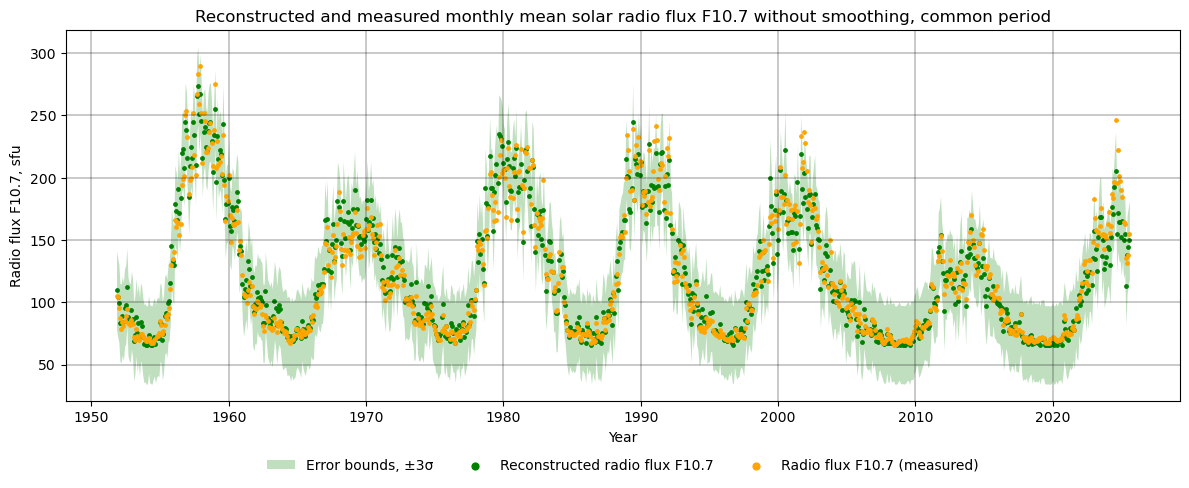

In [17]:
# raw model with +-3 sigma band and measured points on the common period
flux_common_lower_raw = flux_reconstructed_raw - 3 * rmse_raw
flux_common_upper_raw = flux_reconstructed_raw + 3 * rmse_raw

inside_raw = (f_raw >= flux_common_lower_raw) & (f_raw <= flux_common_upper_raw)
print(f"measured points inside ±3σ: {inside_raw.sum()} of {inside_raw.size} ({100 * inside_raw.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(common_time, flux_common_lower_raw, flux_common_upper_raw, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.scatter(common_time, flux_reconstructed_raw, s=6, color="green", label="Reconstructed radio flux F10.7")
ax.scatter(common_time, f_raw, s=6, color="orange", label="Radio flux F10.7 (measured)")
ax.set_title("Reconstructed and measured monthly mean solar radio flux F10.7 without smoothing, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

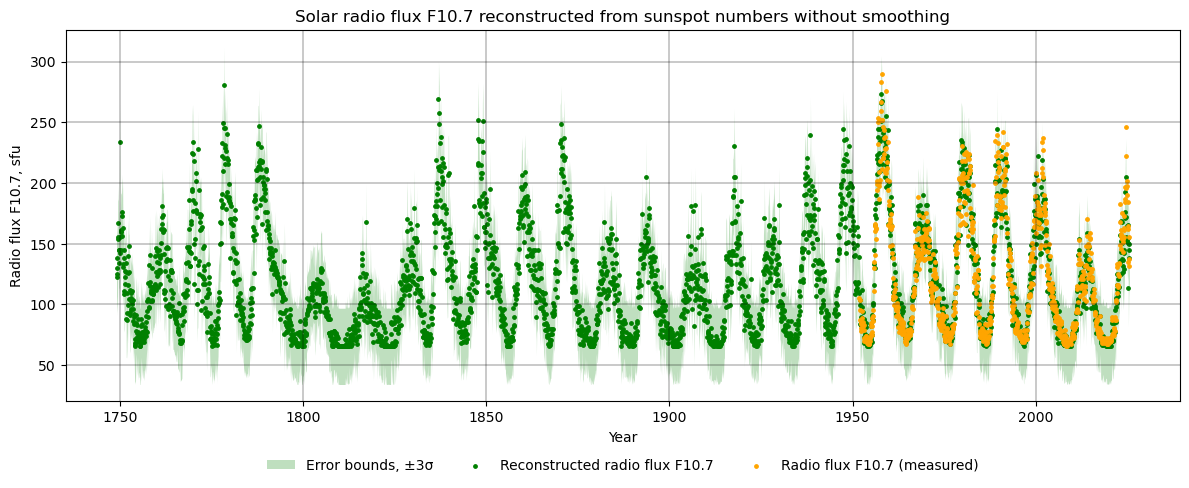

In [20]:
# apply the raw model to the whole period where sunspot numbers are available
R_full_raw = np.column_stack((np.ones(sunspot_raw.size), sunspot_raw, sunspot_raw**2, sunspot_raw**3))
flux_reconstructed_full_raw = (R_full_raw @ beta_raw).ravel()

# error bounds: +-3 sigma
flux_full_lower_raw = flux_reconstructed_full_raw - 3 * rmse_raw
flux_full_upper_raw = flux_reconstructed_full_raw + 3 * rmse_raw

# plotting
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(sunspot_time, flux_full_lower_raw, flux_full_upper_raw, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.scatter(sunspot_time, flux_reconstructed_full_raw, s=6, color="green", label="Reconstructed radio flux F10.7")
ax.scatter(common_time, f_raw, s=6, color="orange", label="Radio flux F10.7 (measured)")
ax.set_title("Solar radio flux F10.7 reconstructed from sunspot numbers without smoothing")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

In [22]:
# compare RMSE with and without smoothing
print(f"{'':42s}{'sigma, sfu':>12s}{'3 sigma, sfu':>14s}")
print(f"{'with smoothing (vs smoothed flux)':42s}{rmse:12.2f}{3 * rmse:14.2f}")
print(f"{'without smoothing (vs raw flux)':42s}{rmse_raw:12.2f}{3 * rmse_raw:14.2f}")

                                            sigma, sfu  3 sigma, sfu
with smoothing (vs smoothed flux)                 9.39         28.18
without smoothing (vs raw flux)                  10.47         31.42
